In [1]:
# Cell 1 - Configure the frozen RQA figure scope
import importlib
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import ListedColormap
import numpy as np

# Optional pandas backends are not required here.
for optional_backend in ("pyarrow", "numexpr", "bottleneck"):
    sys.modules[optional_backend] = None
pd = importlib.import_module("pandas")


def find_phase1_dir(start: Path) -> Path:
    """Locate the phase1 directory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src/rqa/rqa.py").is_file():
            return candidate
        if (candidate / "phase1/src/rqa/rqa.py").is_file():
            return candidate / "phase1"
    raise FileNotFoundError("Could not locate the phase1 directory.")


def require(condition: bool, message: str) -> None:
    """Raise a clear integrity error."""
    if not condition:
        raise ValueError(message)


PHASE1_DIR = find_phase1_dir(Path.cwd())
if str(PHASE1_DIR) not in sys.path:
    sys.path.insert(0, str(PHASE1_DIR))

from src.dataloader.loader import get_data

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message=r"A NumPy version .* is required for this version"
    )
    from src.rqa.rqa import (
        apply_theiler_window,
        compute_distance_matrix,
        compute_fixed_rr_threshold,
        compute_recurrence_matrix,
        reconstruct_phase_space,
    )

OUTPUT_DIR = PHASE1_DIR / "outputs" / "rqa"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SESSION = "sample_1.csv"
WINDOW_SIZE_S = 60
REPRESENTATION = "processed"
EMBEDDING_DIMENSION = 8
TAU_SECONDS = 0.16
TARGET_RR = 0.02
STATES = ("Awake", "Drowsy")
SELECTION_RULE = "Smallest valid window_id within each state"

required_font = "Times New Roman"
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
active_font = required_font if required_font in available_fonts else "Liberation Serif"
if active_font != required_font:
    warnings.warn(
        "Times New Roman is unavailable; using Liberation Serif. "
        "Install Times New Roman before final manuscript export.",
        RuntimeWarning,
        stacklevel=1,
    )
mpl.rcParams.update(
    {
        "font.family": active_font,
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.linewidth": 1.0,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.transparent": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
)
print(
    f"Scope: session 1, {WINDOW_SIZE_S}-s {REPRESENTATION.title()} PPG\n"
    f"Frozen embedding: m={EMBEDDING_DIMENSION}, tau={TAU_SECONDS:.2f} s\n"
    f"Fixed recurrence rate: {100 * TARGET_RR:.1f}%\n"
    f"Selection: {SELECTION_RULE}\nOutput: {OUTPUT_DIR}"
)


Scope: session 1, 60-s Processed PPG
Frozen embedding: m=8, tau=0.16 s
Fixed recurrence rate: 2.0%
Selection: Smallest valid window_id within each state
Output: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa


/tmp/ipykernel_8695/1155948805.py:68: RuntimeWarning: Times New Roman is unavailable; using Liberation Serif. Install Times New Roman before final manuscript export.
  warnings.warn(


### Representative recurrence plots — methodological control

- Awake và Drowsy được lấy từ cùng một session và cùng window length (60 s).
- Toàn bộ reconstruction/RQA parameters được giữ cố định giữa hai trạng thái:
  \[
  m=8,\quad \tau=0.16\,s,\quad RR=0.02
  \]
  cùng Theiler window, \(l_{\min}\) và \(v_{\min}\).
- Vì vậy, khác biệt trực quan giữa hai recurrence plots phản ánh sự thay đổi trong **recurrence geometry** của tín hiệu thay vì khác biệt do parameter setting.
- Do RR được cố định, không diễn giải bằng “nhiều hay ít recurrence points”, mà tập trung vào cách recurrence points tổ chức thành diagonal, vertical và clustered structures.
- Figure chỉ mang tính qualitative; RQA metrics sẽ cung cấp định lượng và inference.

# Chốt RQA metrics

Sử dụng 4 metrics chính:

- **DET** — mức độ recurrence points tổ chức thành diagonal structures.
- **Lmean** — persistence trung bình của diagonal structures.
- **LAM** — mức độ recurrence points tổ chức thành vertical/laminar structures.
- **TT** — trapping/persistence trung bình của vertical structures.

Lý do chọn:

```text
Diagonal dynamics:
DET   → prevalence
Lmean → persistence

Laminar dynamics:
LAM → prevalence
TT  → persistence
````

Bộ 4 này bao phủ hai cấu trúc hình học chính của recurrence plot theo cách đối xứng và dễ diễn giải, đồng thời tránh redundancy.

`ENTR`, `Lmax`, `Vmax` không được giữ trong primary set vì interpretation chồng lấn hoặc phụ thuộc mạnh vào extreme line statistics.

```



In [2]:
# Cell 4 - Load and validate the descriptive RQA scope
RQA_WINDOW_PATH = PHASE1_DIR / "results" / "rqa" / "rqa_window_level.csv"
PRIMARY_METRICS = ("DET", "Lmean", "LAM", "TT")
EXPECTED_SESSIONS = 20
INCLUSION_CANDIDATES = (
    "included",
    "include",
    "is_included",
    "valid",
    "is_valid",
    "qc_pass",
)


def parse_inclusion_flag(series: pd.Series) -> pd.Series:
    """Return a strict Boolean inclusion mask."""
    values = series.astype(str).str.strip().str.casefold()
    truthy = {"true", "1", "1.0", "yes", "pass", "included"}
    falsy = {"false", "0", "0.0", "no", "fail", "excluded"}
    require(
        values.isin(truthy | falsy).all(),
        f"Unsupported values in inclusion flag '{series.name}'.",
    )
    return values.isin(truthy)


rqa_window_raw = pd.read_csv(RQA_WINDOW_PATH)
required_columns = {
    "session",
    "state",
    "window_size",
    "representation",
    "window_id",
    *PRIMARY_METRICS,
}
missing_columns = required_columns.difference(rqa_window_raw.columns)
require(not missing_columns, f"Missing columns: {sorted(missing_columns)}")

inclusion_columns = [
    column for column in INCLUSION_CANDIDATES
    if column in rqa_window_raw.columns
]
require(
    len(inclusion_columns) <= 1,
    f"Ambiguous inclusion flags: {inclusion_columns}",
)
inclusion_column = inclusion_columns[0] if inclusion_columns else None
window_sizes = pd.to_numeric(rqa_window_raw["window_size"], errors="coerce")
scope_mask = (
    rqa_window_raw["representation"].astype(str).str.casefold()
    .eq(REPRESENTATION.casefold())
    & window_sizes.eq(WINDOW_SIZE_S)
    & rqa_window_raw["state"].isin(STATES)
)
rqa_scope = rqa_window_raw.loc[scope_mask].copy()
if inclusion_column is not None:
    included = parse_inclusion_flag(rqa_scope[inclusion_column])
    rqa_scope = rqa_scope.loc[included].copy()

for column in ("window_id", *PRIMARY_METRICS):
    rqa_scope[column] = pd.to_numeric(rqa_scope[column], errors="coerce")
require(not rqa_scope.empty, "No rows remain in the frozen RQA scope.")
duplicate_keys = ["session", "state", "window_id"]
require(
    not rqa_scope.duplicated(duplicate_keys).any(),
    f"Duplicate window keys found: {duplicate_keys}",
)
metric_values = rqa_scope.loc[:, PRIMARY_METRICS].to_numpy(dtype=float)
require(np.isfinite(metric_values).all(), "Primary metrics must be finite.")
coverage = (
    rqa_scope.groupby(["session", "state"]).size().unstack(fill_value=0)
    .reindex(columns=STATES, fill_value=0)
)
require(
    len(coverage) == EXPECTED_SESSIONS,
    f"Expected {EXPECTED_SESSIONS} sessions; found {len(coverage)}.",
)
require(
    coverage.gt(0).all().all(),
    "Every session must contain both Awake and Drowsy windows.",
)
state_counts = rqa_scope["state"].value_counts().reindex(STATES)
flag_note = inclusion_column if inclusion_column else "absent; exported rows used"
print(
    f"Rows: {len(rqa_scope)} | Awake: {state_counts['Awake']} | "
    f"Drowsy: {state_counts['Drowsy']}\n"
    f"Complete sessions: {len(coverage)}/{EXPECTED_SESSIONS}\n"
    f"Inclusion flag: {flag_note}\nQC status: PASS"
)


Rows: 901 | Awake: 596 | Drowsy: 305
Complete sessions: 20/20
Inclusion flag: absent; exported rows used
QC status: PASS


In [3]:
# Cell 5 - Aggregate windows to the session level
session_state = (
    rqa_scope.groupby(["session", "state"], as_index=False)
    .agg(
        n_windows=("window_id", "size"),
        **{metric: (metric, "median") for metric in PRIMARY_METRICS},
    )
)
session_state["_session_order"] = pd.to_numeric(
    session_state["session"].str.extract(r"(\d+)$", expand=False),
    errors="coerce",
)
session_state["_state_order"] = session_state["state"].map(
    dict(zip(STATES, range(len(STATES))))
)
require(
    session_state[["_session_order", "_state_order"]].notna().all().all(),
    "Session or state ordering could not be resolved.",
)
session_state = (
    session_state.sort_values(["_session_order", "_state_order"])
    .drop(columns=["_session_order", "_state_order"])
    .reset_index(drop=True)
)
require(
    len(session_state) == EXPECTED_SESSIONS * len(STATES),
    "Expected one state summary per session and state.",
)
require(
    session_state.groupby("session")["state"].nunique().eq(2).all(),
    "Session-level summaries are not fully paired.",
)

session_pair_table = (
    session_state[["session"]].drop_duplicates().set_index("session")
)
for state in STATES:
    state_key = state.casefold()
    state_rows = session_state.loc[session_state["state"].eq(state)]
    state_rows = state_rows.set_index("session")
    session_pair_table[f"n_windows_{state_key}"] = state_rows["n_windows"]
for metric in PRIMARY_METRICS:
    for state in STATES:
        state_key = state.casefold()
        state_rows = session_state.loc[session_state["state"].eq(state)]
        state_rows = state_rows.set_index("session")
        session_pair_table[f"{metric}_{state_key}"] = state_rows[metric]
session_pair_table = session_pair_table.reset_index()
session_pair_table.insert(1, "representation", REPRESENTATION.title())
session_pair_table.insert(2, "window_size", WINDOW_SIZE_S)
session_summary_path = (
    OUTPUT_DIR / "rqa_session_state_60s_processed.csv"
)
session_pair_table.to_csv(
    session_summary_path, index=False, float_format="%.10g"
)
across_session_medians = (
    session_state.groupby("state")[list(PRIMARY_METRICS)].median()
    .reindex(STATES)
)
print(
    f"Session-state summaries: {len(session_state)} rows "
    f"({EXPECTED_SESSIONS} paired sessions)\n"
    f"Saved: {session_summary_path}"
)
display(across_session_medians.round(4))


Session-state summaries: 40 rows (20 paired sessions)
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_session_state_60s_processed.csv


,DET,Lmean,LAM,TT
state,,,,
Awake,0.7126,4.0132,0.3146,2.0267
Drowsy,0.6983,3.9151,0.3289,2.0331


In [4]:
# Cell 6 - Define the paired-session publication grammar
from matplotlib.lines import Line2D

STATE_COLORS = {"Awake": "#0072B2", "Drowsy": "#D55E00"}
SESSION_LINE_COLOR = "#B8B8B8"
SESSION_HANDLE = Line2D(
    [0],
    [0],
    color=SESSION_LINE_COLOR,
    marker="o",
    markerfacecolor="#777777",
    markeredgecolor="none",
    linewidth=0.8,
    markersize=5,
    label="Session median",
)
MEDIAN_HANDLE = Line2D(
    [0],
    [0],
    color="none",
    marker="D",
    markerfacecolor="white",
    markeredgecolor="black",
    markersize=6,
    label="Across-session median",
)
METRIC_LABELS = {
    "DET": "DET",
    "Lmean": "Lmean (samples)",
    "LAM": "LAM",
    "TT": "TT (samples)",
}


def paired_metric_values(metric: str) -> pd.DataFrame:
    """Return paired session medians for one metric."""
    paired = session_state.pivot(
        index="session", columns="state", values=metric
    ).reindex(columns=STATES)
    require(
        paired.shape == (EXPECTED_SESSIONS, len(STATES)),
        f"Unexpected paired shape for {metric}: {paired.shape}.",
    )
    require(paired.notna().all().all(), f"Missing paired values for {metric}.")
    return paired


def metric_limits(metric: str) -> tuple[float, float]:
    """Set interpretable limits from metric definitions."""
    if metric in {"DET", "LAM"}:
        return 0.0, 1.0
    maximum = float(session_state[metric].max())
    upper = np.ceil((maximum + 0.05 * (maximum - 2.0)) * 2.0) / 2.0
    return 2.0, max(upper, 2.5)


def plot_paired_metric(
    ax: mpl.axes.Axes, metric: str, panel_label: str
) -> None:
    """Plot all paired session medians and the state medians."""
    paired = paired_metric_values(metric)
    x_positions = np.arange(len(STATES), dtype=float)
    offsets = np.linspace(-0.07, 0.07, len(paired))
    for offset, values in zip(offsets, paired.to_numpy()):
        x_values = x_positions + offset
        ax.plot(
            x_values, values, color=SESSION_LINE_COLOR, alpha=0.65,
            linewidth=0.75, zorder=1,
        )
        for x_value, value, state in zip(x_values, values, STATES):
            ax.scatter(
                x_value, value, s=21, color=STATE_COLORS[state],
                alpha=0.78, edgecolors="none", zorder=2,
            )
    ax.scatter(
        x_positions, paired.median(axis=0), s=62, marker="D",
        facecolors="white", edgecolors="black", linewidths=1.1,
        zorder=4,
    )
    ax.set_xticks(x_positions, STATES)
    ax.set_xlim(-0.22, 1.22)
    ax.set_ylim(*metric_limits(metric))
    ax.set_xlabel("State")
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.text(
        0.0, 1.02, panel_label, transform=ax.transAxes, ha="left",
        va="bottom", fontweight="bold",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)


def save_publication_figure(fig: mpl.figure.Figure, stem: Path) -> None:
    """Save vector and 600-dpi publication outputs."""
    fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(
        stem.with_suffix(".png"), dpi=600, bbox_inches="tight"
    )


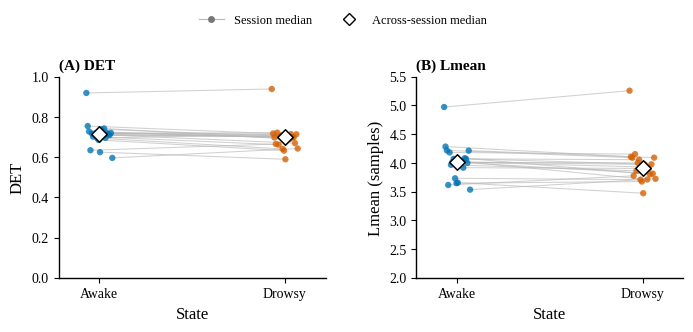

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_diagonal_60s_processed.pdf, .svg, and .png


In [5]:
# Cell 7 - Plot diagonal recurrence dynamics
fig, axes = plt.subplots(1, 2, figsize=(7.10, 3.35))
for ax, metric, panel_label in zip(
    axes, ("DET", "Lmean"), ("(A) DET", "(B) Lmean")
):
    plot_paired_metric(ax, metric, panel_label)
fig.legend(
    handles=(SESSION_HANDLE, MEDIAN_HANDLE), loc="upper center",
    bbox_to_anchor=(0.5, 1.01), frameon=False, ncol=2, fontsize=9,
)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.19, top=0.79, wspace=0.34)
diagonal_stem = OUTPUT_DIR / "rqa_diagonal_60s_processed"
save_publication_figure(fig, diagonal_stem)
plt.show()
print(f"Saved: {diagonal_stem}.pdf, .svg, and .png")


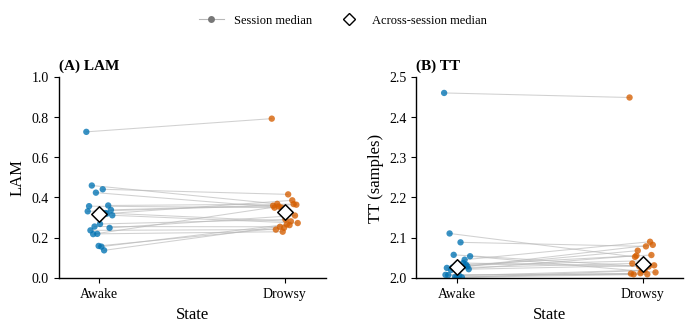

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_laminar_60s_processed.pdf, .svg, and .png


In [6]:
# Cell 8 - Plot laminar recurrence dynamics
fig, axes = plt.subplots(1, 2, figsize=(7.10, 3.35))
for ax, metric, panel_label in zip(
    axes, ("LAM", "TT"), ("(A) LAM", "(B) TT")
):
    plot_paired_metric(ax, metric, panel_label)
fig.legend(
    handles=(SESSION_HANDLE, MEDIAN_HANDLE), loc="upper center",
    bbox_to_anchor=(0.5, 1.01), frameon=False, ncol=2, fontsize=9,
)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.19, top=0.79, wspace=0.34)
laminar_stem = OUTPUT_DIR / "rqa_laminar_60s_processed"
save_publication_figure(fig, laminar_stem)
plt.show()
print(f"Saved: {laminar_stem}.pdf, .svg, and .png")


In [7]:
# Cell 9 - Save the non-inferential descriptive summary
descriptive_rows = []
for metric in PRIMARY_METRICS:
    paired = paired_metric_values(metric)
    differences = paired["Drowsy"] - paired["Awake"]
    ties = np.isclose(differences, 0.0, rtol=1e-9, atol=1e-12)
    awake_median = float(paired["Awake"].median())
    drowsy_median = float(paired["Drowsy"].median())
    descriptive_rows.append(
        {
            "metric": metric,
            "awake_median": awake_median,
            "drowsy_median": drowsy_median,
            "drowsy_median_minus_awake_median": (
                drowsy_median - awake_median
            ),
            "n_drowsy_gt_awake": int(((differences > 0) & ~ties).sum()),
            "n_drowsy_lt_awake": int(((differences < 0) & ~ties).sum()),
            "n_drowsy_eq_awake": int(ties.sum()),
        }
    )
descriptive_summary = pd.DataFrame(descriptive_rows)
sign_columns = [
    "n_drowsy_gt_awake",
    "n_drowsy_lt_awake",
    "n_drowsy_eq_awake",
]
require(
    descriptive_summary[sign_columns].sum(axis=1)
    .eq(EXPECTED_SESSIONS).all(),
    "Direction counts must sum to the paired session count.",
)
descriptive_path = OUTPUT_DIR / "rqa_descriptive_60s_processed.csv"
descriptive_summary.to_csv(
    descriptive_path, index=False, float_format="%.10g"
)
print(
    descriptive_summary.to_string(
        index=False, float_format=lambda value: f"{value:.4f}"
    )
)
print(f"\nSaved: {descriptive_path}")
print("No inferential tests were run in this descriptive section.")


metric  awake_median  drowsy_median  drowsy_median_minus_awake_median  n_drowsy_gt_awake  n_drowsy_lt_awake  n_drowsy_eq_awake
   DET        0.7126         0.6983                           -0.0143                  5                 15                  0
 Lmean        4.0132         3.9151                           -0.0982                  4                 16                  0
   LAM        0.3146         0.3289                            0.0143                 13                  7                  0
    TT        2.0267         2.0331                            0.0064                 14                  6                  0

Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_descriptive_60s_processed.csv
No inferential tests were run in this descriptive section.


In [8]:
# Cell 10 - Run paired session-level statistical validation
from scipy.stats import rankdata, wilcoxon

BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 20_260_829
pair_source = session_pair_table.copy()
pair_columns = [
    "session",
    "representation",
    "window_size",
    "n_windows_awake",
    "n_windows_drowsy",
]
metric_pair_columns = [
    f"{metric}_{state.casefold()}"
    for metric in PRIMARY_METRICS
    for state in STATES
]
required_pair_columns = set(pair_columns + metric_pair_columns)
missing_pair_columns = required_pair_columns.difference(pair_source.columns)
require(
    not missing_pair_columns,
    f"Missing session-level columns: {sorted(missing_pair_columns)}",
)
require(
    len(pair_source) == EXPECTED_SESSIONS,
    f"Expected {EXPECTED_SESSIONS} paired sessions.",
)
require(
    pair_source["session"].is_unique,
    "Session-level inference requires one row per session.",
)
require(
    np.isfinite(pair_source[metric_pair_columns].to_numpy(dtype=float)).all(),
    "All paired metric values must be finite.",
)


def bootstrap_median_ci(
    differences: np.ndarray,
    rng: np.random.Generator,
    n_resamples: int,
) -> tuple[float, float]:
    """Return a percentile bootstrap CI for the median."""
    samples = rng.choice(
        differences,
        size=(n_resamples, len(differences)),
        replace=True,
    )
    bootstrap_medians = np.median(samples, axis=1)
    lower, upper = np.percentile(bootstrap_medians, [2.5, 97.5])
    return float(lower), float(upper)


def matched_pairs_rank_biserial(differences: np.ndarray) -> float:
    """Compute signed matched-pairs rank-biserial correlation."""
    nonzero = differences != 0.0
    if not nonzero.any():
        return 0.0
    signed_differences = differences[nonzero]
    ranks = rankdata(np.abs(signed_differences), method="average")
    positive_sum = ranks[signed_differences > 0.0].sum()
    negative_sum = ranks[signed_differences < 0.0].sum()
    return float((positive_sum - negative_sum) / ranks.sum())


seed_sequences = np.random.SeedSequence(BOOTSTRAP_SEED).spawn(
    len(PRIMARY_METRICS)
)
comparison_rows = []
paired_values = pair_source[pair_columns].copy()
paired_value_columns = pair_columns.copy()
for metric, seed_sequence in zip(PRIMARY_METRICS, seed_sequences):
    awake_column = f"{metric}_awake"
    drowsy_column = f"{metric}_drowsy"
    delta_column = f"{metric}_delta"
    awake = pair_source[awake_column].to_numpy(dtype=float)
    drowsy = pair_source[drowsy_column].to_numpy(dtype=float)
    differences = drowsy - awake
    differences[np.isclose(differences, 0.0, rtol=1e-9, atol=1e-12)] = 0.0

    paired_values[awake_column] = awake
    paired_values[drowsy_column] = drowsy
    paired_values[delta_column] = differences
    paired_value_columns.extend(
        [awake_column, drowsy_column, delta_column]
    )

    rng = np.random.default_rng(seed_sequence)
    ci_low, ci_high = bootstrap_median_ci(
        differences, rng, BOOTSTRAP_RESAMPLES
    )
    if np.any(differences != 0.0):
        wilcoxon_result = wilcoxon(
            differences,
            alternative="two-sided",
            zero_method="wilcox",
            correction=False,
            method="auto",
        )
        wilcoxon_statistic = float(wilcoxon_result.statistic)
        raw_p_value = float(wilcoxon_result.pvalue)
    else:
        wilcoxon_statistic = 0.0
        raw_p_value = 1.0

    n_positive = int(np.sum(differences > 0.0))
    n_negative = int(np.sum(differences < 0.0))
    n_zero = int(np.sum(differences == 0.0))
    require(
        n_positive + n_negative + n_zero == EXPECTED_SESSIONS,
        f"Direction counts do not sum to {EXPECTED_SESSIONS} for {metric}.",
    )
    comparison_rows.append(
        {
            "metric": metric,
            "n_sessions": EXPECTED_SESSIONS,
            "awake_median": float(np.median(awake)),
            "drowsy_median": float(np.median(drowsy)),
            "median_delta": float(np.median(differences)),
            "bootstrap_ci_low": ci_low,
            "bootstrap_ci_high": ci_high,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "bootstrap_seed": BOOTSTRAP_SEED,
            "wilcoxon_statistic": wilcoxon_statistic,
            "raw_p_value": raw_p_value,
            "rank_biserial_r_rb": matched_pairs_rank_biserial(
                differences
            ),
            "n_positive": n_positive,
            "n_negative": n_negative,
            "n_zero": n_zero,
        }
    )

rqa_state_comparison = pd.DataFrame(comparison_rows)
paired_values = paired_values[paired_value_columns]
comparison_path = OUTPUT_DIR / "rqa_state_comparison_60s_processed.csv"
paired_values_path = (
    OUTPUT_DIR / "rqa_state_paired_values_60s_processed.csv"
)
rqa_state_comparison.to_csv(
    comparison_path, index=False, float_format="%.10g"
)
paired_values.to_csv(
    paired_values_path, index=False, float_format="%.10g"
)
print(
    f"Paired inference: {EXPECTED_SESSIONS} sessions, "
    f"{BOOTSTRAP_RESAMPLES:,} bootstrap resamples\n"
    f"Saved: {comparison_path}\n"
    f"Saved: {paired_values_path}"
)


Paired inference: 20 sessions, 20,000 bootstrap resamples
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_state_comparison_60s_processed.csv
Saved: /home/vutu0809/Desktop/NTSA_Foundation/phase1/outputs/rqa/rqa_state_paired_values_60s_processed.csv


In [9]:
# Cell 11 - Print the compact statistical validation summary
compact_rows = []
for row in rqa_state_comparison.to_dict(orient="records"):
    compact_rows.append(
        {
            "Metric": row["metric"],
            "Awake median": f"{row['awake_median']:.4f}",
            "Drowsy median": f"{row['drowsy_median']:.4f}",
            "Median Delta": f"{row['median_delta']:.4f}",
            "95% bootstrap CI": (
                f"[{row['bootstrap_ci_low']:.4f}, "
                f"{row['bootstrap_ci_high']:.4f}]"
            ),
            "raw p": f"{row['raw_p_value']:.4g}",
            "rank-biserial r_rb": f"{row['rank_biserial_r_rb']:.3f}",
            "positive/negative/zero": (
                f"{row['n_positive']}/{row['n_negative']}/{row['n_zero']}"
            ),
        }
    )
compact_validation = pd.DataFrame(compact_rows)
print(compact_validation.to_string(index=False))


def metric_effect_text(metric: str) -> str:
    """Format a direction and effect-size description."""
    row = rqa_state_comparison.set_index("metric").loc[metric]
    return (
        f"{metric}: median Delta={row['median_delta']:.4f}, "
        f"r_rb={row['rank_biserial_r_rb']:.3f}, "
        f"+/-/0={int(row['n_positive'])}/"
        f"{int(row['n_negative'])}/{int(row['n_zero'])}"
    )


print(
    "\nDirectional effect-size interpretation:\n"
    "- Diagonal recurrence organization/persistence: "
    f"{metric_effect_text('DET')}; {metric_effect_text('Lmean')}.\n"
    "- Laminar recurrence/trapping persistence: "
    f"{metric_effect_text('LAM')}; {metric_effect_text('TT')}.\n"
    "Raw p-values are retained without BH-FDR. No multiplicity-controlled "
    "significance claim is made before the joint Prediction + RQA + LLE "
    "primary test family is complete."
)


Metric Awake median Drowsy median Median Delta   95% bootstrap CI   raw p rank-biserial r_rb positive/negative/zero
   DET       0.7126        0.6983      -0.0186 [-0.0364, -0.0069] 0.02148             -0.581                 5/15/0
 Lmean       4.0132        3.9151      -0.0630 [-0.1247, -0.0139] 0.05826             -0.486                 4/16/0
   LAM       0.3146        0.3289       0.0165  [-0.0044, 0.0635]  0.1429              0.381                 13/7/0
    TT       2.0267        2.0331       0.0095  [-0.0034, 0.0160]  0.2024              0.333                 14/6/0

Directional effect-size interpretation:
- Diagonal recurrence organization/persistence: DET: median Delta=-0.0186, r_rb=-0.581, +/-/0=5/15/0; Lmean: median Delta=-0.0630, r_rb=-0.486, +/-/0=4/16/0.
- Laminar recurrence/trapping persistence: LAM: median Delta=0.0165, r_rb=0.381, +/-/0=13/7/0; TT: median Delta=0.0095, r_rb=0.333, +/-/0=14/6/0.
Raw p-values are retained without BH-FDR. No multiplicity-controlled signif

### RQA — Awake–Drowsy comparison và statistical validation

Phân tích được thực hiện trên **60-s Processed PPG** với `session` là đơn vị replication.  
Trong mỗi `session × state`, các window được tổng hợp bằng median trước khi so sánh paired giữa Awake và Drowsy.

#### 1. Quan sát từ session-level plots

Hai nhóm RQA metrics cho hai pattern khác nhau:

**Diagonal recurrence**
- `DET` nhìn chung giảm từ Awake → Drowsy.
- `Lmean` cũng có xu hướng giảm.
- Direction giảm xuất hiện ở phần lớn session, cho thấy sự suy giảm tương đối nhất quán của diagonal recurrence organization/persistence.

**Laminar recurrence**
- `LAM` có xu hướng tăng từ Awake → Drowsy.
- `TT` cũng có xu hướng tăng.
- Tuy nhiên, mức thay đổi nhỏ hơn và heterogeneity giữa các session rõ hơn so với nhóm diagonal metrics.

Nhìn chung, plots gợi ý:

\[
\text{Diagonal organization/persistence} \downarrow
\]

đồng thời với một xu hướng yếu hơn:

\[
\text{Laminar recurrence/trapping} \uparrow
\]

---

#### 2. Paired statistical validation

Với mỗi session:

\[
\Delta_i = Drowsy_i - Awake_i
\]

Kết quả:

| Metric | Median \(\Delta\) | Bootstrap 95% CI | Raw \(p\) | \(r_{rb}\) | Direction |
|---|---:|---:|---:|---:|---:|
| DET | -0.0186 | [-0.0364, -0.0069] | 0.0215 | -0.581 | 15/20 ↓ |
| Lmean | -0.0630 | [-0.1247, -0.0139] | 0.0583 | -0.486 | 16/20 ↓ |
| LAM | +0.0165 | [-0.0044, +0.0635] | 0.1429 | +0.381 | 13/20 ↑ |
| TT | +0.0095 | [-0.0034, +0.0160] | 0.2024 | +0.333 | 14/20 ↑ |

#### 3. Diễn giải

**Diagonal recurrence cho bằng chứng rõ hơn:**
- `DET` giảm với CI hoàn toàn dưới 0, effect size theo hướng âm và 15/20 session cùng direction.
- `Lmean` cũng giảm ở 16/20 session và CI bootstrap hoàn toàn dưới 0, hỗ trợ cùng một construct mặc dù raw Wilcoxon \(p\) chưa dưới 0.05.

→ Hai metric hội tụ về:

> **Drowsiness làm giảm diagonal recurrence organization và persistence.**

**Laminar recurrence cho bằng chứng yếu hơn:**
- `LAM` và `TT` đều có median \(\Delta>0\) và phần lớn session tăng.
- Tuy nhiên CI của cả hai đều cắt 0 và effect sizes nhỏ hơn.

→ Hiện chỉ nên diễn giải là:

> **Drowsiness có xu hướng làm tăng laminar recurrence/trapping, nhưng effect yếu hơn và heterogeneous hơn so với thay đổi diagonal.**

---

### RQA finding hiện tại

Bằng chứng RQA chủ yếu hỗ trợ một sự **reorganization của recurrence geometry**, trong đó finding mạnh nhất là:

\[
\boxed{\text{Diagonal recurrence organization/persistence} \downarrow}
\]

kèm theo một xu hướng hỗ trợ nhưng yếu hơn:

\[
\boxed{\text{Laminar recurrence/trapping} \uparrow}
\]

Các raw \(p\)-values hiện chưa được dùng để đưa ra multiplicity-controlled significance claim.  
BH-FDR sẽ được thực hiện sau khi hoàn tất toàn bộ primary family gồm **Prediction + RQA + LLE**.